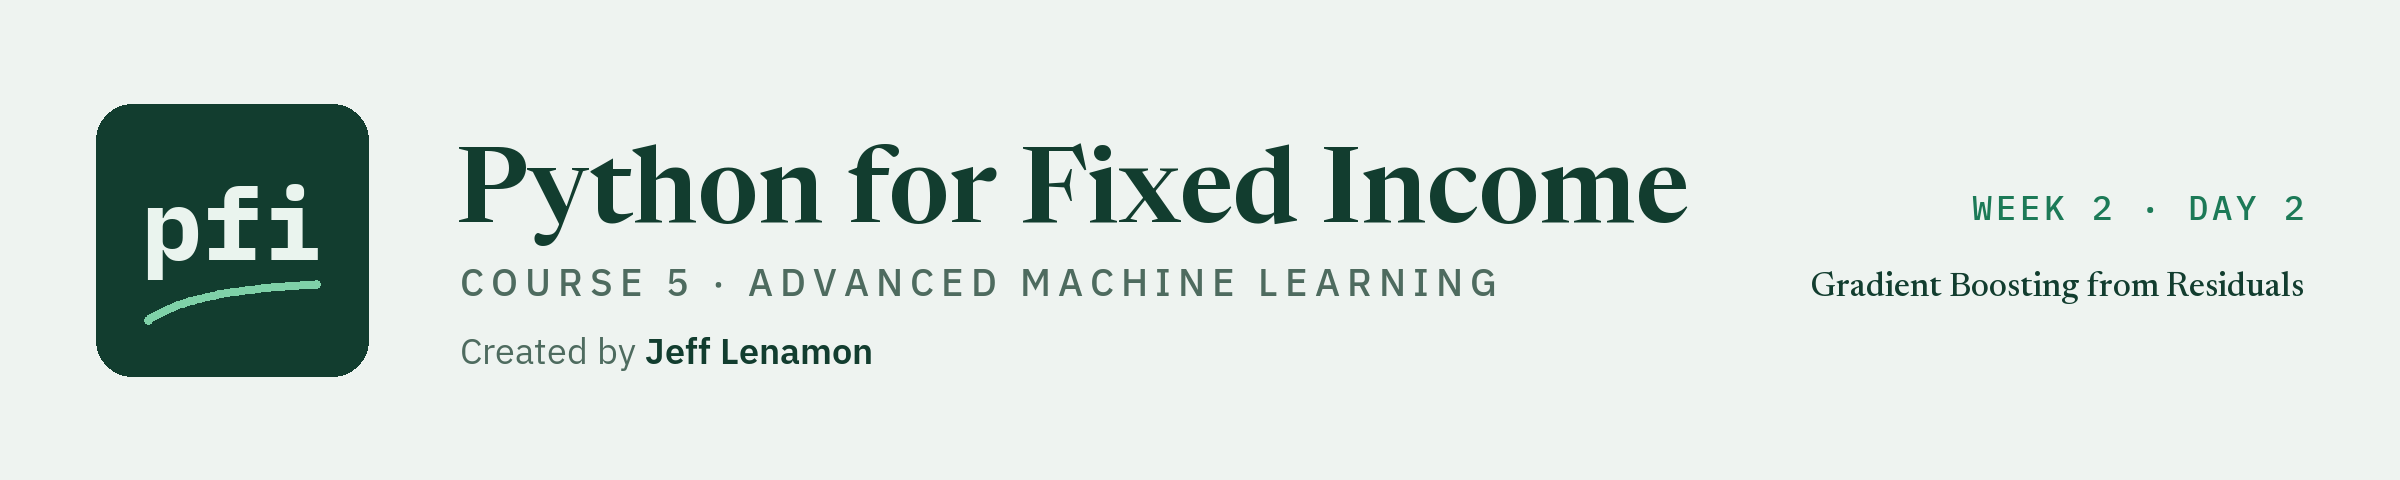

# Gradient Boosting from Residuals

Week 2, Day 2. Week 2 trains trees one after another. Today: gradient boosting built by hand from residuals on the benchmark's log spreads, matched to scikit-learn to 1e-12, and measured against Course 4's OLS by cross-validated MAE in bp.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week2/day2/07_gradient_boosting_from_residuals.ipynb)

Yesterday's AdaBoost reweighted the rows each round so the next stump looked harder at the accounts the last one missed. Gradient boosting does the same job in a way that is easier to see on a number: **start every bond at the average spread, fit a small tree to what is left over, add a fraction of that tree, and repeat.** Each round's tree is fitted to the residuals of all the rounds before it. Today that is built by hand on the benchmark, a regression task, and checked against scikit-learn's `GradientBoostingRegressor` to twelve decimal places.

**The benchmark rules, as on every benchmark day in this course.**

* **The bonds are invented.** `benchmark.csv` holds 821 bonds of invented issuers, and their spreads come from the course's generator, `tools/make_holdings.py` (read today, never run). No real issuer, price, or spread is in it.
* **Course 4's split, rebuilt.** `ensemblekit.course4_bench_rows` returns Course 4's 615 training bonds; Course 4's 206 test bonds stay closed for the whole course, by the test-row rule day 1 stated for the card file. Every score today is cross-validated inside the 615.
* **A model's output is a fitted spread.** It is "the model's spread for a bond with these characteristics", and the gap to the bond's own spread is a residual. No fitted spread is a fair value, and no residual is a trade.
* The card file is copied into the work folder only because earlier days' tests read it; no model today uses it.

Today you will:

1. Start from the mean and look at the residuals.
2. Find the first stump by hand: the one question that most reduces the squared residuals.
3. Write `boost_by_hand` and match `GradientBoostingRegressor` for 100 rounds.
4. Chart the learning rate against the number of rounds, by cross-validated MAE in bp, with `mae_bp`.
5. See what depth adds: stumps add one feature at a time; depth 2 lets two interact.
6. Put boosting beside Course 4's OLS, without and with coupon.
7. Find where the gain comes from in the generator itself.
8. Name the classification version and the fast version.

Q. Set up today's work folder: the thread settings, the seed, the course data, and the modules as day 6 left them.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_07_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_07_hvap2_v3, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, credit_card_default.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)


from types import SimpleNamespace

from sklearn.ensemble import RandomForestClassifier


class StandInTree:
    """A stand-in for a fitted tree: its class-1 output is the first column plus a constant."""

    def __init__(self, shift: float):
        self.shift = shift

    def predict_proba(self, values: np.ndarray) -> np.ndarray:
        p = values[:, 0] / 10 + self.shift
        return np.column_stack([1 - p, p])


def test_tree_correlation_hand():
    X = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0], "b": [0.0, 0.0, 1.0, 1.0]})
    # two outputs that differ by a constant are perfectly correlated
    forest = SimpleNamespace(estimators_=[StandInTree(0.1), StandInTree(0.3)])
    assert ensemblekit.tree_correlation(forest, X) == pytest.approx(1.0, abs=1e-12)


def test_tree_correlation_forest_below_bagging():
    X, y = card_small()
    _, X_valid, _, _ = card_rows()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED,
                                n_jobs=1).fit(X, y)
    forest = RandomForestClassifier(n_estimators=10, random_state=SEED, n_jobs=1).fit(X, y)
    assert forest.estimators_[0].max_features == "sqrt"
    assert ensemblekit.tree_correlation(forest, X_valid) < ensemblekit.tree_correlation(bagging, X_valid)


def test_tree_correlation_rejects_one_tree():
    X, y = card_small(500)
    forest = RandomForestClassifier(n_estimators=1, random_state=SEED, n_jobs=1).fit(X, y)
    with pytest.raises(ValueError, match="at least two trees"):
        ensemblekit.tree_correlation(forest, X)


from sklearn.inspection import permutation_importance


@cache
def forest_with_noise() -> tuple[RandomForestClassifier, pd.DataFrame, pd.Series]:
    """A 50-tree forest with 20-row leaves on 3,000 training rows plus a column of random numbers, and 2,000
    validation rows with their own random column."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    rng = np.random.default_rng(SEED)
    X = X.assign(noise=rng.normal(size=len(X)))
    X_valid = X_valid.iloc[:2_000].assign(noise=rng.normal(size=2_000))
    forest = RandomForestClassifier(n_estimators=50, min_samples_leaf=20, random_state=SEED, n_jobs=1).fit(X, y)
    return forest, X_valid, y_valid.iloc[:2_000]


def test_importance_table_columns_and_ranks():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    assert list(table.columns) == ["impurity", "permutation", "permutation_sd", "impurity_rank", "permutation_rank"]
    assert set(table.index) == set(X_valid.columns)
    assert table["impurity"].sum() == pytest.approx(1.0, abs=1e-12)
    assert table["permutation"].is_monotonic_decreasing
    assert table["permutation_rank"].iloc[0] == 1
    assert table.loc[table["impurity"].idxmax(), "impurity_rank"] == 1


def test_importance_table_matches_permutation_importance():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid, n_repeats=3)
    direct = permutation_importance(forest, X_valid, y_valid, scoring="roc_auc", n_repeats=3, random_state=SEED,
                                    n_jobs=1)
    expected = pd.Series(direct.importances_mean, index=X_valid.columns)
    assert table["permutation"].to_numpy() == pytest.approx(expected[table.index].to_numpy(), abs=1e-12)


def test_importance_table_noise_near_zero():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    # on unseen rows, shuffling a column of random numbers costs (almost) nothing
    assert abs(table.loc["noise", "permutation"]) < 0.01
    assert table.loc["PAY_0", "permutation"] > 10 * abs(table.loc["noise", "permutation"])


def test_importance_table_rejects_model_without_importances():
    X, y = card_small(500)
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X, y)
    with pytest.raises(ValueError, match="feature_importances_"):
        ensemblekit.importance_table(model, X, y)


from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted


@cache
def bench_rows() -> pd.DataFrame:
    """Course 4's 615 training bonds."""
    return ensemblekit.course4_bench_rows(pd.read_csv(HERE / "benchmark.csv"), pd.read_csv(HERE / "ratings.csv"))


def test_course4_bench_rows_counts_and_closed():
    train = bench_rows()
    assert len(train) == 615
    assert {"score", "log_oas", "years", "amount_bn"} <= set(train.columns)
    assert train["log_oas"].to_numpy() == pytest.approx(np.log(train["oas"]).to_numpy(), abs=1e-12)
    # Course 4's test bonds, recomputed with Course 4's call on the file
    bench = pd.read_csv(HERE / "benchmark.csv")
    _, bench_test = train_test_split(bench, test_size=0.25, random_state=SEED)
    assert len(bench_test) == 206
    assert not set(bench_test["cusip"]) & set(train["cusip"])
    with pytest.raises(ValueError):
        ensemblekit.course4_bench_rows(bench.iloc[:800], pd.read_csv(HERE / "ratings.csv"))


def test_oof_threshold_meets_recall():
    X, y = card_small()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    threshold, proba = ensemblekit.oof_threshold(model, X, y, target_recall=0.70)
    assert proba.shape == (len(X),)
    flagged = proba >= threshold
    assert flagged[y.to_numpy() == 1].mean() >= 0.70
    # the next higher distinct probability would miss the target
    higher = np.unique(proba[proba > threshold])
    if higher.size:
        assert (proba >= higher[0])[y.to_numpy() == 1].mean() < 0.70


def test_oof_threshold_does_not_fit_callers_model():
    X, y = card_small(1_000)
    model = DecisionTreeClassifier(max_depth=3, random_state=SEED)
    ensemblekit.oof_threshold(model, X, y)
    with pytest.raises(NotFittedError):
        check_is_fitted(model)


from sklearn.ensemble import AdaBoostClassifier


def test_samme_alpha_hand():
    # right on 80 percent of the weight: ln(0.8 / 0.2) = ln 4
    assert ensemblekit.samme_alpha(0.2) == pytest.approx(np.log(4), abs=1e-12)
    assert ensemblekit.samme_alpha(0.2, learning_rate=0.5) == pytest.approx(0.5 * np.log(4), abs=1e-12)


def test_samme_alpha_rejects_error_at_half():
    for error in (0.5, 0.0, 0.7):
        with pytest.raises(ValueError):
            ensemblekit.samme_alpha(error)


def test_reweight_sums_to_one():
    new = ensemblekit.reweight(np.full(4, 0.25), np.array([1, 0, 0, 0]), np.log(3))
    # the missed row is multiplied by 3: weights 3, 1, 1, 1 over 6
    assert new == pytest.approx([0.5, 1 / 6, 1 / 6, 1 / 6], abs=1e-12)
    assert new.sum() == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, -0.5]), np.array([1, 0]), 1.0)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, 0.5]), np.array([1, 0, 0]), 1.0)


def test_three_rounds_match_sklearn():
    X, y = card_small()
    ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=3,
                             random_state=SEED).fit(X, y)
    # three rounds by hand: fit a stump on the weights, measure its weighted error, weight it, reweight the rows
    weights = np.full(len(X), 1 / len(X))
    alphas = []
    for _ in range(3):
        stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X, y, sample_weight=weights)
        missed = (stump.predict(X) != y.to_numpy()).astype(float)
        error = float(np.sum(weights * missed) / np.sum(weights))
        alphas.append(ensemblekit.samme_alpha(error))
        weights = ensemblekit.reweight(weights, missed, alphas[-1])
    assert alphas == pytest.approx(ada.estimator_weights_.tolist(), abs=1e-12)

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag', 'bagged_proba', 'oob_auc', 'tree_correlation', 'importance_table', 'course4_bench_rows', 'oof_threshold', 'samme_alpha', 'reweight']


* `ensemblekit.py` and `test_ensemblekit.py` are written as day 6 left them, 25 tests. Today adds two functions and three tests.

Q. Start today's repository now, before anything changes, so tonight's commit holds only today's work.

In [6]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [7]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_07_hvap2_v3 and nowhere else


Q. Tell Git which files never to track, and commit the three module files as they stand.

In [8]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [9]:
# the data files are copies of the course's data and stay untracked
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "Start of day 7: ensemblekit as day 6 left it"
!git -C "{work}" log --oneline

ea58093 Start of day 7: ensemblekit as day 6 left it


* One commit with the files as they stand at the start of the day. The Git section at the end commits today's change on top of it and reads it back.

## 7.1 Start from the Mean

Gradient boosting for a squared error has three moves:

1. **Start from the mean.** Before any tree, every bond's fitted value is the average of the target.
2. **Fit a tree to the residuals.** The residual is what the current fitted value leaves unexplained: the target minus the fit.
3. **Add a fraction of it.** The tree's output, times a **learning rate** such as 0.1, is added to every bond's fitted value. Then go back to step 2 with the new residuals.

The target is `log_oas`, the natural log of the spread in bp, as in Course 4: a model of log spreads treats a 10 bp miss on a 50 bp bond as bigger than a 10 bp miss on a 500 bp bond.

Q. Load the benchmark and take Course 4's training bonds.

In [10]:
# the synthetic benchmark: 821 bonds of invented issuers, and the rating scale
bench = pd.read_csv("benchmark.csv")
ratings = pd.read_csv("ratings.csv")

# Course 4's split, rebuilt: the 615 training bonds only, with score, log_oas, years, and amount_bn added
train = ensemblekit.course4_bench_rows(bench, ratings)
y = train["log_oas"]
print(f"benchmark bonds: {len(bench)}; Course 4's training bonds: {len(train)}; test bonds, never returned: {len(bench) - len(train)}")
print(f"target: log_oas, the natural log of the spread in bp; spreads from {train['oas'].min()} to {train['oas'].max()} bp")

benchmark bonds: 821; Course 4's training bonds: 615; test bonds, never returned: 206
target: log_oas, the natural log of the spread in bp; spreads from 15 to 2074 bp


* 615 training bonds. The bonds and their spreads are invented: the generator in `tools/make_holdings.py` made them, from a rating, a maturity, an issuer effect, and noise.

Q. Round 0: every bond starts at the mean log spread. What is left over?

In [11]:
# round 0: one fitted value for every bond, the mean of the target
f0 = y.mean()
residual = y - f0

print(f"mean log spread: {f0:.4f}, which is {np.exp(f0):.1f} bp after exp")
print(f"sum of squared residuals around the mean: {(residual ** 2).sum():.4f}")
print(train[["cusip", "rating", "score", "oas", "log_oas"]].assign(residual=residual).head().round(4).to_string())

mean log spread: 4.8776, which is 131.3 bp after exp
sum of squared residuals around the mean: 354.1335
         cusip rating  score  oas  log_oas  residual
712  99130AAC6     A+      5   49   3.8918   -0.9858
181  99035JAB5     A+      5   59   4.0775   -0.8000
778  99143NAC3     AA      3   22   3.0910   -1.7865
716  99131BAC3   BBB-     10  217   5.3799    0.5023
636  99116MAD6   BBB+      8  128   4.8520   -0.0255


* Round 0 fits every bond at 4.8776 in log units, 131.3 bp after `exp`. That is the mean of the logs, so after `exp` it is a geometric mean, below the plain average spread.
* A bond's residual is positive where its spread is above that level and negative where it is below. The sum of their squares, 354.1335, is what every later round tries to shrink.

## 7.2 The First Stump by Hand

Round 1 fits a **stump**, a tree with one question, to the residuals. For a squared error the stump's job is plain: try every column and every threshold, split the bonds in two, give each side the mean residual of its bonds, and keep the split that leaves the smallest sum of squared residuals. Three columns today: `score` (the rating as a number, 1 = AAA), `duration`, and `years` to maturity.

Q. Search every threshold of each column by hand. Which question wins?

In [12]:
X3 = train[["score", "duration", "years"]]


def best_split(x, r):
    """The threshold on one column that leaves the smallest sum of squared residuals around the two leaf means."""
    values = np.sort(np.unique(x))
    best = None
    # candidate thresholds: halfway between neighbouring values, as a tree places them
    for t in (values[:-1] + values[1:]) / 2:
        left, right = r[x <= t], r[x > t]
        sse = ((left - left.mean()) ** 2).sum() + ((right - right.mean()) ** 2).sum()
        if best is None or sse < best[1]:
            best = (t, sse, len(left), left.mean(), right.mean())
    return best


splits = pd.DataFrame({column: best_split(X3[column].to_numpy(), residual.to_numpy()) for column in X3.columns},
                      index=["threshold", "squared residuals left", "bonds on the left", "left mean", "right mean"]).T
print(splits.sort_values("squared residuals left").round(4).to_string())

          threshold  squared residuals left  bonds on the left  left mean  right mean
score        9.5000                150.4572              327.0    -0.5401      0.6132
duration    13.1445                346.9504              592.0     0.0213     -0.5483
years       10.9952                347.2643              476.0    -0.0571      0.1956


* The best question is `score <= 9.5`: it leaves 150.4572 of the 354.1335 squared residuals, against 346.9504 for the best split on `duration`. Score 9 is BBB and 10 is BBB-, so the stump separates the 327 bonds rated AAA to BBB from the 288 rated BBB- and below.
* The two leaf values are mean residuals in log units around the mean: -0.5401 on the left and 0.6132 on the right. Added in full, they would put the left bonds at 76.5 bp and the right bonds at 242.4 bp after `exp`.

Q. Does scikit-learn's stump agree?

In [13]:
from sklearn.tree import DecisionTreeRegressor

# a one-question regression tree fitted to the residuals; no criterion= is passed (scikit-learn's default is squared error)
stump = DecisionTreeRegressor(max_depth=1, random_state=SEED).fit(X3, residual)
tree = stump.tree_
print(f"scikit-learn's stump: {X3.columns[tree.feature[0]]} <= {tree.threshold[0]}, "
      f"leaf values {tree.value[1, 0, 0]:.4f} ({tree.n_node_samples[1]} bonds) and {tree.value[2, 0, 0]:.4f} ({tree.n_node_samples[2]} bonds)")
best = splits.sort_values("squared residuals left").iloc[0]
print(f"equal to the hand search within 1e-12: {abs(tree.value[1, 0, 0] - best['left mean']) < 1e-12 and abs(tree.value[2, 0, 0] - best['right mean']) < 1e-12}")

scikit-learn's stump: score <= 9.5, leaf values -0.5401 (327 bonds) and 0.6132 (288 bonds)
equal to the hand search within 1e-12: True


* The same question, the same 327 and 288 bonds, the same leaf values. A regression stump is a search for the split with the smallest squared residuals, and the leaf values are mean residuals; nothing more.

Q. Add a tenth of the stump to every bond's fitted value. Is that round 1 of `GradientBoostingRegressor`?

In [14]:
from sklearn.ensemble import GradientBoostingRegressor

# round 1: the mean plus a learning rate of 0.1 times the stump's output
learning_rate = 0.1
f1 = f0 + learning_rate * stump.predict(X3)

# the library's first round: one stump, the same learning rate
one_round = GradientBoostingRegressor(n_estimators=1, learning_rate=0.1, max_depth=1, random_state=SEED).fit(X3, y)
print(f"round 1 by hand equals GradientBoostingRegressor's first round within 1e-12: {np.abs(f1 - one_round.predict(X3)).max() < 1e-12}")
print(f"after round 1: {np.exp(f1.min()):.1f} bp for score <= 9.5 and {np.exp(f1.max()):.1f} bp above, from {np.exp(f0):.1f} bp for all")

round 1 by hand equals GradientBoostingRegressor's first round within 1e-12: True
after round 1: 124.4 bp for score <= 9.5 and 139.6 bp above, from 131.3 bp for all


* Round 1 moves the left bonds from 131.3 to 124.4 bp and the right bonds to 139.6 bp: a tenth of the way in log units. The library's first round is exactly this.
* Why only a tenth? The stump is fitted to these bonds' noise as well as their pattern. A small step leaves room for later trees to correct it, which is the job of the learning rate (section 7.4).

## 7.3 `boost_by_hand` for 100 Rounds

Round 2 does the same with what round 1 left, and so on. A loop of three lines.

Q. Add `boost_by_hand` to `ensemblekit.py`. Read the docstring first.

In [15]:
%%writefile -a ensemblekit.py


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted

Appending to ensemblekit.py


* `fitted` starts as the mean of the target, one value per row. Each round fits a `DecisionTreeRegressor` of the chosen depth to `target - fitted`, the residuals, and adds `learning_rate` times its output.
* The tree gets `random_state=seed` because a tree breaks ties between equally good splits at random; with a fixed seed it breaks them the same way the library does.

Q. Add its two tests: 100 rounds against scikit-learn, and one round as the mean plus a stump.

In [16]:
%%writefile -a test_ensemblekit.py


from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor


def test_boost_by_hand_matches_sklearn():
    train = bench_rows()
    X, y = train[["score", "duration", "years"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=100, learning_rate=0.1, max_depth=2)
    library = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=SEED).fit(X, y)
    assert fitted == pytest.approx(library.predict(X), abs=1e-12)


def test_boost_by_hand_one_round_is_mean_plus_stump():
    train = bench_rows()
    X, y = train[["score"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=1, learning_rate=0.5, max_depth=1)
    stump = DecisionTreeRegressor(max_depth=1, random_state=SEED).fit(X, y - y.mean())
    assert fitted == pytest.approx(y.mean() + 0.5 * stump.predict(X), abs=1e-12)
    # a stump has two leaves, so one round gives two distinct fitted values
    assert len(np.unique(fitted.round(12))) == 2
    with pytest.raises(ValueError):
        ensemblekit.boost_by_hand(X, y, n_rounds=0, learning_rate=0.1, max_depth=1)

Appending to test_ensemblekit.py


Q. Reload the module and run the tests.

In [17]:
# the file changed, so reload before using the new function
importlib.reload(ensemblekit)
print(f"boost_by_hand in ensemblekit: {hasattr(ensemblekit, 'boost_by_hand')}")

boost_by_hand in ensemblekit: True


In [18]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# the run time changes from run to run, so a duration over a minute is left out of the summary line
import re
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

...........................                                              [100%]
27 passed in 12.67s



* `27 passed`: day 6's 25 and the two new ones.

Q. Boost 100 rounds of depth-2 trees by hand and with scikit-learn. Do they agree, and how does the fit move for three bonds?

In [19]:
# 100 rounds of depth-2 trees, learning rate 0.1, by hand and by the library, on the 615 training bonds
fitted_hand = ensemblekit.boost_by_hand(X3, y, n_rounds=100, learning_rate=0.1, max_depth=2)
library = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=SEED).fit(X3, y)
print(f"boost_by_hand equals GradientBoostingRegressor within 1e-12: {np.abs(fitted_hand - library.predict(X3)).max() < 1e-12}")

# three bonds: their own spread, and the fitted spread after 1, 10, and 100 rounds, in bp
path = pd.DataFrame({"oas (bp)": train["oas"].iloc[:3].to_numpy()}, index=train["cusip"].iloc[:3])
for rounds in (1, 10, 100):
    fitted = ensemblekit.boost_by_hand(X3, y, n_rounds=rounds, learning_rate=0.1, max_depth=2)
    path[f"after {rounds}"] = np.exp(fitted[:3]).round(1)
print(path.to_string())

boost_by_hand equals GradientBoostingRegressor within 1e-12: True


           oas (bp)  after 1  after 10  after 100
cusip                                            
99130AAC6        49    118.4      75.6       53.8
99035JAB5        59    118.4      75.6       59.4
99143NAC3        22    118.4      61.2       33.7


* Equal within 1e-12 on all 615 bonds: scikit-learn's `GradientBoostingRegressor` with a squared error is these three lines.
* Each bond's fitted spread walks from the mean toward its own level, a little each round. The first bond, at 49 bp, is fitted at 118.4 bp after one round, 75.6 after ten, and 53.8 after 100. These are fitted spreads on rows the model was fitted on: they describe the fit, and say nothing yet about bonds it has not seen.

> **STORY: where the method's name comes from.** In October 2001 Jerome H. Friedman published a paper titled "Greedy function approximation: A gradient boosting machine." in *The Annals of Statistics* (volume 29, issue 5; the record gives no page range). Its title holds the name of what section 7.3 just built: a model grown one small tree at a time, each round taking the step that most reduces what is left.
>
> Source (read 2026-10-05): the Crossref record of the paper, https://api.crossref.org/works/10.1214/aos/1013203451, DOI https://doi.org/10.1214/aos/1013203451. Only the title, author, journal, volume, issue, and date are taken from it; the paper itself was not read for this course.

## 7.4 The Learning Rate against the Number of Rounds

A smaller learning rate takes smaller steps, so it needs more rounds to get as far. Too few rounds and the model has not learned the pattern; too many and it starts fitting the training bonds' noise. To see where that happens, score on bonds the model did not see: five folds of the 615 training bonds, each bond fitted by the fold model that left it out, and the course's metric, **mean absolute error in bp after `exp`**.

Q. Add `mae_bp` and its test.

In [20]:
%%writefile -a ensemblekit.py


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))

Appending to ensemblekit.py


In [21]:
%%writefile -a test_ensemblekit.py


def test_mae_bp_hand():
    # spreads of 100 and 200 bp fitted at 110 and 180 bp: errors 10 and 20 bp
    log_true, log_fitted = np.log([100.0, 200.0]), np.log([110.0, 180.0])
    assert ensemblekit.mae_bp(log_true, log_fitted) == pytest.approx(15.0, abs=1e-9)
    with pytest.raises(ValueError):
        ensemblekit.mae_bp([1.0], [1.0, 2.0])

Appending to test_ensemblekit.py


* `exp` of a fitted log spread is a spread in bp, so the error is in bp, the unit a desk reads. The hand test: spreads of 100 and 200 bp fitted at 110 and 180 bp miss by 10 and 20 bp, an MAE of 15.

Q. Reload and run all of today's tests.

In [22]:
importlib.reload(ensemblekit)
print(f"mae_bp in ensemblekit: {hasattr(ensemblekit, 'mae_bp')}")

mae_bp in ensemblekit: True


In [23]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# the run time changes from run to run, so a duration over a minute is left out of the summary line
import re
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

............................                                             [100%]
28 passed in 13.15s



* `28 passed`.

The features from here on are the ones Course 4's case study gave OLS, as day 5 gave them to its forest: `score` for the rating (a tree splits an ordered number directly), `sector` as indicator columns, and `duration`, `years`, and `amount_bn` as they are, unscaled (a tree's splits do not depend on scale). The indicator columns are made inside a `Pipeline`, so each fold learns the list of sectors from its own training bonds.

Q. For four learning rates, cross-validate depth-2 boosting up to 1,000 rounds, and record the MAE in bp after every round.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

NUMBERS = ["score", "duration", "years", "amount_bn"]
FEATURES = NUMBERS + ["sector"]


def boosting(depth, n_rounds, learning_rate, numbers=NUMBERS):
    """Gradient boosting on log_oas: sector as indicator columns, the rating as its number (score), the numbers as they are."""
    encode = ColumnTransformer([("sector", OneHotEncoder(handle_unknown="ignore"), ["sector"]),
                                ("numbers", "passthrough", numbers)])
    model = GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=learning_rate, max_depth=depth, random_state=SEED)
    return Pipeline([("encode", encode), ("model", model)])


# Course 4's regression folds: five, shuffled with seed 42
folds = mlkit.cv_folds("regression")
curves = {}
for rate in [0.3, 0.1, 0.05, 0.01]:
    # one row per round, one column per bond: each bond's fitted log spread from the fold model that did not see it
    staged = np.zeros((1000, len(train)))
    for fit_rows, held_rows in folds.split(train):
        model = boosting(2, 1000, rate).fit(train[FEATURES].iloc[fit_rows], y.iloc[fit_rows])
        encoded = model[:-1].transform(train[FEATURES].iloc[held_rows])
        # staged_predict gives the fitted values after round 1, 2, ..., 1000 without refitting
        for k, fitted in enumerate(model[-1].staged_predict(encoded)):
            staged[k, held_rows] = fitted
    curves[rate] = pd.Series([ensemblekit.mae_bp(y, staged[k]) for k in range(1000)], index=range(1, 1001))

summary = pd.DataFrame({rate: {"lowest MAE (bp)": c.min(), "at round": c.idxmin(), "MAE at 100": c[100],
                               "MAE at 300": c[300], "MAE at 1000": c[1000]} for rate, c in curves.items()}).T
summary.index.name = "learning rate"
# a round number is a whole number; the MAEs in bp to 1 decimal
summary = summary.round(1).astype({"at round": int})
print(summary.to_string())

               lowest MAE (bp)  at round  MAE at 100  MAE at 300  MAE at 1000
learning rate                                                                
0.30                      33.6        86        33.8        35.6         40.0
0.10                      34.9       923        39.5        36.6         35.1
0.05                      35.8       973        40.2        38.2         35.8
0.01                      39.0      1000        61.1        42.1         39.0


**Rows.** Every model on the benchmark in this notebook is fitted and scored inside Course 4's 615 training bonds, by five folds wherever a score is reported; Course 4's 206 test bonds are never scored in this course.

* At a learning rate of 0.3 the cross-validated MAE is lowest after 86 rounds (33.6 bp) and then rises to 40.0 bp at 1,000: big steps learn fast, then fit the training bonds' noise.
* At 0.01 the model is still improving at round 1,000 (39.0 bp) and is far off after 100 rounds (61.1 bp): small steps need many rounds. At 0.1 and 0.05 the lowest point comes after 923 and 973 rounds.
* Every number is a fitted spread scored against the bond's own spread on a bond its fold model never saw.

Q. Draw the four curves.

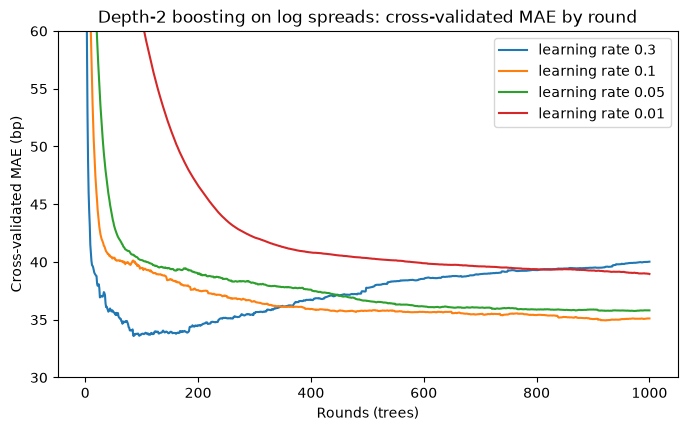

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
for rate, curve in curves.items():
    ax.plot(curve.index, curve.values, label=f"learning rate {rate}")
ax.set_ylim(30, 60)
ax.set_title("Depth-2 boosting on log spreads: cross-validated MAE by round")
ax.set_xlabel("Rounds (trees)")
ax.set_ylabel("Cross-validated MAE (bp)")
ax.legend()
plt.show()

* The learning rate and the number of rounds trade against each other: the lower curves at 0.05 and 0.01 take longer to come down, and the 0.3 curve turns up after its low.
* **These curves describe; they do not choose.** The lowest point on this chart is the best of 4,000 numbers measured on the same five folds, so it flatters whichever setting happened to fit these folds' noise. The comparison in section 7.6 uses one setting fixed before looking: 300 rounds at a learning rate of 0.05. Day 8 picks the number of rounds by early stopping on rows carved from the training rows, and day 11 shows how to report a chosen setting honestly.

## 7.5 Depth: One Feature at a Time, or Two Together

A stump asks one question about one column, so each round adds a step in one feature. However many rounds there are, the model is a sum of separate pieces: a curve in score plus a curve in years, with no term that depends on both. A depth-2 tree asks a second question inside the first, so one round can say "long bonds, **if** high yield". That is an **interaction**.

Q. Fit 300 rounds of stumps and of depth-2 trees on score and years. Does the effect of going from 2 to 20 years depend on the rating?

In [26]:
SY = ["score", "years"]
grid = pd.DataFrame({"score": [5, 5, 12, 12], "years": [2, 20, 2, 20]})

for depth in (1, 2):
    model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=depth, random_state=SEED).fit(train[SY], y)
    f = model.predict(grid)
    # the step from 2 to 20 years, in log units, for score 5 (A+) and score 12 (BB)
    step_ig, step_hy = f[1] - f[0], f[3] - f[2]
    columns_per_tree = [len(set(t.tree_.feature[t.tree_.feature >= 0])) for t in model.estimators_[:, 0]]
    print(f"depth {depth}: 2 to 20 years adds {step_ig:.4f} at score 5 and {step_hy:.4f} at score 12; "
          f"difference {step_hy - step_ig:.4f}; trees using two columns: {columns_per_tree.count(2)} of {len(columns_per_tree)}")

depth 1: 2 to 20 years adds 0.2179 at score 5 and 0.2179 at score 12; difference 0.0000; trees using two columns: 0 of 300


depth 2: 2 to 20 years adds 0.2126 at score 5 and 0.2606 at score 12; difference 0.0481; trees using two columns: 160 of 300


* With stumps the step from 2 to 20 years is the same at score 5 and at score 12: the difference is zero to 4 decimals (below 1e-12), because a sum of one-column pieces cannot make one column's effect depend on another. Every stump uses one column.
* With depth 2 the step differs by 0.0481 in log units (0.2126 at score 5, 0.2606 at score 12), and 160 of the 300 trees ask about both columns. The deeper trees fitted an interaction. These are fits on the 615 bonds they were fitted on, so they say nothing yet about whether the interaction holds on bonds the model did not see.

Q. The benchmark is synthetic, so the generator can settle it. In logs, its spread line (shown in full in section 7.7) is a rating term plus a maturity term plus an issuer effect and noise: there is no term in score times years. Cross-validate stumps and depth 2 on score and years, then with duration added.

In [27]:
from sklearn.model_selection import cross_val_predict

# section 7.4's five folds; each bond fitted by the fold model that did not see it
for columns in (["score", "years"], ["score", "duration", "years"]):
    for depth in (1, 2):
        model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=depth, random_state=SEED)
        fitted = cross_val_predict(model, train[columns], y, cv=folds, n_jobs=1)
        print(f"{' + '.join(columns)}, depth {depth}: cross-validated MAE {ensemblekit.mae_bp(y, fitted):.1f} bp")

score + years, depth 1: cross-validated MAE 39.9 bp


score + years, depth 2: cross-validated MAE 40.7 bp


score + duration + years, depth 1: cross-validated MAE 40.0 bp


score + duration + years, depth 2: cross-validated MAE 36.2 bp


* On score and years, stumps fit the held-out bonds at 39.9 bp and depth 2 at 40.7 bp: the interaction depth 2 fitted above is not in the generator, and it costs accuracy on bonds the model did not see.
* With duration added, depth 2 wins: 36.2 bp against 40.0 for stumps. The generator computes each bond's duration from its coupon and its yield, and the yield is the Treasury yield plus the spread (`bond_yield = round(round(float(treasury_yield(years_to_maturity)), 3) + oas / 100, 3)`). So duration, like coupon, carries part of the spread itself. Which combination of columns the depth-2 trees use for it is not tested here.
* Depth is a choice about the data: interactions help where the data holds one, and fit noise where it does not.

## 7.6 Boosting beside Course 4's OLS

Course 4's case study fitted OLS of `log_oas` on rating and sector indicators and four scaled numbers: duration, years, coupon, and amount. It found coupon partly restates the spread (a bond's coupon was set from its yield when it was issued), so the comparison runs twice: **without coupon** and **with coupon**. Every model gets the same five folds, and boosting gets the fixed setting: 300 rounds at a learning rate of 0.05.

Q. Cross-validate OLS, boosted stumps, and boosted depth-2 trees, without and with coupon, and compare MAE in bp.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


def ols(numbers):
    """Course 4's case study pipeline: rating and sector indicators (references A and Consumer), numbers scaled."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), numbers)])
    return Pipeline([("encode", encode), ("model", LinearRegression())])


NO_COUPON = ["duration", "years", "amount_bn"]
candidates = {
    ("OLS", "without coupon"): (ols(NO_COUPON), ["rating", "sector"] + NO_COUPON),
    ("boosting, stumps", "without coupon"): (boosting(1, 300, 0.05), FEATURES),
    ("boosting, depth 2", "without coupon"): (boosting(2, 300, 0.05), FEATURES),
    ("OLS", "with coupon"): (ols(NO_COUPON + ["coupon"]), ["rating", "sector"] + NO_COUPON + ["coupon"]),
    ("boosting, stumps", "with coupon"): (boosting(1, 300, 0.05, NUMBERS + ["coupon"]), FEATURES + ["coupon"]),
    ("boosting, depth 2", "with coupon"): (boosting(2, 300, 0.05, NUMBERS + ["coupon"]), FEATURES + ["coupon"]),
}
# each bond's fitted log spread from the fold model that did not see it, then MAE in bp and R-squared on log_oas
oof = {key: cross_val_predict(model, train[columns], y, cv=folds, n_jobs=1) for key, (model, columns) in candidates.items()}
table = pd.DataFrame({"MAE (bp)": {key: ensemblekit.mae_bp(y, f) for key, f in oof.items()},
                      "R-squared (log)": {key: mlkit.regression_metrics(y, f)["r2"] for key, f in oof.items()}})
table.index.names = ["model", "features"]
print(table.round(4).to_string())
print(f"depth 2 without coupon equals the 0.05 curve at round 300: {abs(table.iloc[2, 0] - curves[0.05][300]) < 1e-12}")

                                  MAE (bp)  R-squared (log)
model             features                                 
OLS               without coupon   41.7166           0.8799
boosting, stumps  without coupon   40.0452           0.8871
boosting, depth 2 without coupon   38.1729           0.8999
OLS               with coupon      37.1878           0.8984
boosting, stumps  with coupon      37.1587           0.9025
boosting, depth 2 with coupon      37.1142           0.9047
depth 2 without coupon equals the 0.05 curve at round 300: True


* **Without coupon**, boosting with depth-2 trees fits the held-out bonds at 38.2 bp, stumps at 40.0, and OLS at 41.7: boosting is 3.5 bp closer, and depth 2 beats stumps by 1.9.
* **With coupon**, the gap almost closes: depth 2 at 37.1 bp against OLS at 37.2, 0.1 bp. Coupon carries much of the spread already (Course 4's finding), and what is left for trees to find is small.
* These are fitted spreads on bonds each fold model did not see. The 300-round setting was fixed in advance; the chart in section 7.4 shows other settings would print other numbers, some lower, on these same folds.

Q. Write the results to the experiment log.

In [29]:
# Course 5's regression log: model, features, rows, MAE in bp, R-squared on log_oas
results = pd.DataFrame([{"model": model.replace(", ", "_").replace(" ", "_"),
                         "features": ("rating" if model == "OLS" else "score") + "_sector_duration_years_amount"
                                     + ("_coupon" if features == "with coupon" else ""),
                         "rows": "cv", "mae_bp": row["MAE (bp)"], "r2": row["R-squared (log)"]}
                        for (model, features), row in table.iterrows()])
# 4 decimals and LF line endings, so a diff shows a real change and prints the same everywhere
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,features,rows,mae_bp,r2
OLS,rating_sector_duration_years_amount,cv,41.7166,0.8799
boosting_stumps,score_sector_duration_years_amount,cv,40.0452,0.8871
boosting_depth_2,score_sector_duration_years_amount,cv,38.1729,0.8999
OLS,rating_sector_duration_years_amount_coupon,cv,37.1878,0.8984
boosting_stumps,score_sector_duration_years_amount_coupon,cv,37.1587,0.9025
boosting_depth_2,score_sector_duration_years_amount_coupon,cv,37.1142,0.9047



* Course 5's regression log: `model, features, rows, mae_bp, r2`, with `rows` set to `cv` because every number is cross-validated inside the training bonds. It is committed in the Git section.

## 7.7 Where the Gain Comes From

The benchmark is synthetic, so the true pattern can be read, not guessed. This is the line in `tools/make_holdings.py` that sets each bond's spread:

```python
oas = BASE_OAS[score] * (0.70 + 0.30 * min(years_to_maturity, 10) / 10) * issuer_effect * rng.lognormal(0, 0.18)
```

The maturity term rises with years to maturity and **stops rising at 10 years**: `min(years_to_maturity, 10)`. A straight line in years cannot bend at 10. A tree can: one question, `years <= 10`, puts a step where the generator put its cap.

Q. Fit OLS and depth-2 boosting on score and years alone. How far apart are they?

In [30]:
# two columns only: score and years; OLS fits a straight line in each
oof_ols = cross_val_predict(LinearRegression(), train[SY], y, cv=folds, n_jobs=1)
oof_boost = cross_val_predict(GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=2, random_state=SEED),
                              train[SY], y, cv=folds, n_jobs=1)
print(f"score and years only: OLS {ensemblekit.mae_bp(y, oof_ols):.1f} bp, boosting {ensemblekit.mae_bp(y, oof_boost):.1f} bp")

# the average out-of-fold residual (log units) by years to maturity: where each model misses
by_years = pd.DataFrame({"bonds": y.groupby(pd.cut(train["years"], [0, 2, 4, 6, 8, 10, 12, 20, 30]), observed=False).size(),
                         "OLS residual": (y - oof_ols).groupby(pd.cut(train["years"], [0, 2, 4, 6, 8, 10, 12, 20, 30]), observed=False).mean(),
                         "boosting residual": (y - oof_boost).groupby(pd.cut(train["years"], [0, 2, 4, 6, 8, 10, 12, 20, 30]), observed=False).mean()})
by_years.index.name = "years"
print(by_years.round(4).to_string())

score and years only: OLS 42.3 bp, boosting 40.7 bp
          bonds  OLS residual  boosting residual
years                                           
(0, 2]       74       -0.0634             0.0042
(2, 4]       78       -0.0262             0.0098
(4, 6]       93       -0.0666            -0.0069
(6, 8]       81        0.0215            -0.0124
(8, 10]     108        0.0729            -0.0020
(10, 12]     84        0.0729             0.0139
(12, 20]     34        0.0903             0.0019
(20, 30]     63       -0.0962            -0.0131


* On two columns, depth-2 boosting fits the held-out bonds at 40.7 bp and OLS at 42.3 bp. Section 7.5's stumps did better still on the same two columns, 39.9 bp: a bend in one column needs no interaction, so one-column steps are enough to draw it.
* The residuals show where the straight line misses. A residual is the bond's log spread minus the fit, so a negative average means the model fits those bonds too wide. OLS's average residual is -0.0634 up to 2 years, positive from 8 to 20 years (up to 0.0903), and -0.0962 above 20 years (63 bonds). One slope has to serve a spread that rises up to 10 years and stops: it is too shallow for the short end, so short bonds come out too wide, and it keeps rising past 10 years, so the longest bonds come out too wide as well. Boosting's average residuals stay within 0.0139 of zero in every bucket, because its trees put steps where the data bends.
* That is where much of boosting's lead comes from on this file: a shape the straight line cannot draw. Day 12 writes the cap as a feature, `min(years, 10)`, and gives OLS the bend by hand.

Q. Draw both models' average residual by years to maturity.

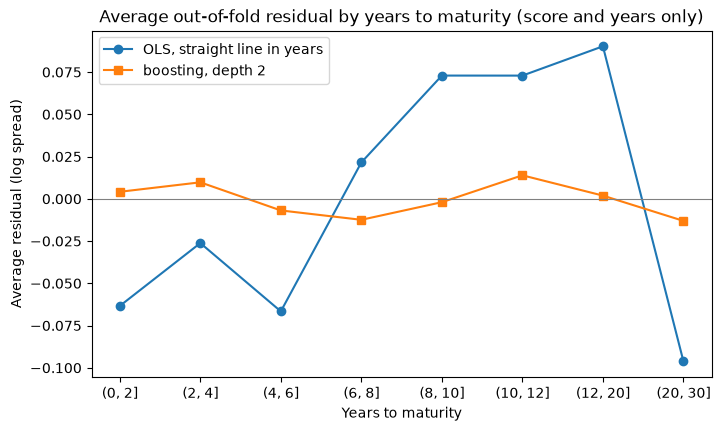

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [str(interval) for interval in by_years.index]
ax.plot(labels, by_years["OLS residual"], marker="o", label="OLS, straight line in years")
ax.plot(labels, by_years["boosting residual"], marker="s", label="boosting, depth 2")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Average out-of-fold residual by years to maturity (score and years only)")
ax.set_xlabel("Years to maturity")
ax.set_ylabel("Average residual (log spread)")
ax.legend()
plt.show()

* OLS's line is below zero at both ends and above it in the middle: the mark a straight line leaves on a rise that stops at 10 years. Boosting's stays near zero.

## 7.8 Gradient Boosting for Classification, Named

The same three moves work for a default flag, on a different scale. `GradientBoostingClassifier` starts every account at the **log-odds** of the default rate, fits each round's tree to the gap between the outcome (0 or 1) and the current probability, and adds a fraction of the tree's output to the log-odds. The output is turned into a probability with the logistic function at the end, as Course 4's logistic regression did. The residual on that scale is called a gradient, which is where the name comes from: each round steps down the slope of the loss.

XGBoost and LightGBM, days 8 and 9, are this classification version with more controls. Day 8 uses it on the card file.

## 7.9 `HistGradientBoostingRegressor`, the Fast Version

`GradientBoostingRegressor` tries every threshold of every column in every round, as `best_split` did. `HistGradientBoostingRegressor` first sorts each column's values into at most 255 bins and only tries the bin edges, so on a file of many rows it tries far fewer thresholds. It also grows trees by a number of leaves (31 by default) rather than by depth, and takes missing values as they are, which matters for the Polish file in week 3. On 615 bonds there is nothing to gain, so it is named here and not fitted.

## Excel Side by Side

Excel has no worksheet function for gradient boosting. It can do one round of it, though, and a second, because a stump on one column is two `AVERAGEIFS` and an `IF`. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-05), with the 615 training bonds' `score` pasted in column A and `log_oas` in column B. Both of the first two rounds split on score (the library chose 9.5 and then 10.5); the thresholds come from Python and go in a cell, M2 and M3, and the learning rate 0.1 in M1.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Round 0: the mean | `y.mean()` | `=AVERAGE(B2:B616)` in M4, and `=$M$4` down column E | 4.8776 |
| Residual after round 0 | `y - f0` | `=B2-E2` down column F | equal to Python |
| Left leaf, round 1 | stump's left value | `=AVERAGEIFS(F2:F616,A2:A616,"<="&M2)` | -0.5401 |
| Right leaf, round 1 | stump's right value | `=AVERAGEIFS(F2:F616,A2:A616,">"&M2)` | 0.6132 |
| Round 1 fitted value | `f0 + 0.1 * stump.predict(X3)` | `=E2+$M$1*IF(A2<=$M$2,$M$5,$M$6)` down column G | equal to the library's first round |
| Residual after round 1 | `y - f1` | `=B2-G2` down column H | equal to Python |
| Leaves, round 2 | second stump | `=AVERAGEIFS(H2:H616,A2:A616,"<="&M3)` and `=AVERAGEIFS(H2:H616,A2:A616,">"&M3)` | -0.3833 and 0.7340 |
| Round 2 fitted value | `staged_predict`, round 2 | `=G2+$M$1*IF(A2<=$M$3,$M$7,$M$8)` down column I | equal to the library's second round |
| MAE in bp of a log model | `ensemblekit.mae_bp(y, f)` | `=AVERAGE(ABS(EXP(B2:B616)-EXP(D2:D616)))` | 38.1729 |

**Round 1 at your desk.** `=AVERAGE(B2:B616)` is round 0. Column F is each bond's residual. `AVERAGEIFS` takes the average of the residuals for the rows whose score passes a test: `"<="&M2` joins the text `<=` to the threshold, so the test reads `<=9.5`, the stump's left side, and `">"&M2` is its right side. Those two averages are the stump's leaf values. Column G adds a tenth of the right one to each bond: `IF(A2<=$M$2,$M$5,$M$6)` picks the leaf the bond falls in.

**Round 2** repeats the same three steps on column G's residuals with the second threshold. Each further round would add three columns: that is why boosting lives in code.

**MAE in bp.** With the out-of-fold fitted log spreads of section 7.6's depth-2 model (without coupon) pasted in column D, `=AVERAGE(ABS(EXP(B2:B616)-EXP(D2:D616)))` takes `EXP` of both columns, the absolute gaps, and their average in one formula; typed as a dynamic-array formula, it gives section 7.6's number.

Q. Do Excel's numbers equal Python's?

In [32]:
# the library's first two rounds of stumps on the same three columns
two_rounds = GradientBoostingRegressor(n_estimators=2, learning_rate=0.1, max_depth=1, random_state=SEED).fit(X3, y)
second = two_rounds.estimators_[1, 0].tree_
stages = list(two_rounds.staged_predict(X3))

# Excel's numbers, from the course's Excel check, beside Python's for the same bonds
excel = {"round 0: mean log spread": 4.8775756761243425,
         "round 1: left leaf": -0.5400762027257491,
         "round 1: right leaf": 0.6132115218448715,
         "round 2: left leaf": -0.38332570159365764,
         "round 2: right leaf": 0.7339506324352633,
         "round 2: first bond's fitted value": 4.785235485692402,
         "MAE in bp, depth 2 without coupon": 38.172858320024055}
python = {"round 0: mean log spread": f0,
          "round 1: left leaf": stump.tree_.value[1, 0, 0],
          "round 1: right leaf": stump.tree_.value[2, 0, 0],
          "round 2: left leaf": second.value[1, 0, 0],
          "round 2: right leaf": second.value[2, 0, 0],
          "round 2: first bond's fitted value": stages[1][0],
          "MAE in bp, depth 2 without coupon": table.iloc[2, 0]}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
side_by_side

,Excel,Python,within 1e-12
round 0: mean log spread,4.877576,4.877576,True
round 1: left leaf,-0.540076,-0.540076,True
round 1: right leaf,0.613212,0.613212,True
round 2: left leaf,-0.383326,-0.383326,True
round 2: right leaf,0.733951,0.733951,True
round 2: first bond's fitted value,4.785235,4.785235,True
"MAE in bp, depth 2 without coupon",38.172858,38.172858,True


* Every number matches within 1e-12, and the script checked all 615 fitted values of both rounds, not only the first bond's. One round of gradient boosting is two conditional averages and an `IF`; the library repeats that hundreds of times with deeper trees.

## Save the Day with Git

The morning's commit holds the files as day 6 left them. Commit today's change on top, then the experiment log.

Q. Commit today's two functions and their tests.

In [33]:
# M marks a tracked file that changed since the last commit
!git -C "{work}" status --short
!git -C "{work}" add ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "Gradient boosting from residuals: boost_by_hand and mae_bp, 28 tests"

 M ensemblekit.py
 M test_ensemblekit.py
?? benchmark.csv
?? credit_card_default.csv
?? ratings.csv
?? results.csv


In [34]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: cross-validated MAE in bp of OLS and boosting on the benchmark"
!git -C "{work}" log --oneline

08132bc Experiment log: cross-validated MAE in bp of OLS and boosting on the benchmark
fb55500 Gradient boosting from residuals: boost_by_hand and mae_bp, 28 tests
ea58093 Start of day 7: ensemblekit as day 6 left it


* Three commits: the start of the day, the code, the results. The data files are copies and stay untracked.

Q. Today's Git step: what did the last commit that touched `ensemblekit.py` change in it?

In [35]:
# -p shows the patch, -1 the last commit only, and -- ensemblekit.py limits it to commits that touched that file
!git -C "{work}" log -p -1 -- ensemblekit.py

commit fb555009c508ec00e805660567074961a06bcc23
Author: Course Student <student@example.com>
Date:   Mon Oct 5 20:52:54 2026 -0400

    Gradient boosting from residuals: boost_by_hand and mae_bp, 28 tests

diff --git a/ensemblekit.py b/ensemblekit.py
index 13794b2..6b96f38 100644
--- a/ensemblekit.py
+++ b/ensemblekit.py
@@ -266,3 +266,47 @@ def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarra
     # a missed row is multiplied by e^alpha, a correct row by 1
     new = w * np.exp(alpha * m)
     return new / new.sum()
+
+
+from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals
+
+
+def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
+    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.
+
+    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
+    the fracti

* `git log -p -1 -- ensemblekit.py` skipped the results commit, which did not touch the module, and showed the code commit: its message, then the patch. Lines starting with `+` were added, and no line was removed, because today only appended. The patch is exactly today's two functions and the import above them.
* In your own `my_bondmath` folder the same command answers "what did I change in the module last time?" without scrolling through every commit.

## Bring It Home

Add today's functions to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code. The benchmark and ratings files are there from day 5.

**Step 1.** Go to your folder and activate the course's environment.

```powershell
Set-Location "$HOME\projects\my_bondmath"
& "$HOME\projects\python-fixed-income\.venv\Scripts\Activate.ps1"
```

**Step 2.** Paste the code of today's two `%%writefile -a ensemblekit.py` cells (sections 7.3 and 7.4), without their first lines, at the end of `ensemblekit.py`; do the same for the two `test_ensemblekit.py` cells. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_ensemblekit.py
```

The last line says `28 passed`.

**Step 4.** Read the change, commit it, and read it back with today's Git step.

```powershell
git diff --stat
git add ensemblekit.py test_ensemblekit.py
git commit -m "Gradient boosting from residuals: boost_by_hand and mae_bp, 28 tests"
git log -p -1 -- ensemblekit.py
```

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say what gradient boosting does each round: fit a small tree to the residuals and add a fraction of it.
* Find a regression stump by hand and check it against scikit-learn.
* Build gradient boosting with `boost_by_hand` and match `GradientBoostingRegressor` to 1e-12.
* Read a learning-rate chart, and say why its lowest point is not an honest score.
* Say what depth adds: one feature at a time for stumps, interactions from depth 2.
* Compare boosting with OLS by cross-validated MAE in bp with `mae_bp`, and find in the generator where the gain comes from.
* Do one round of boosting in Excel with `AVERAGEIFS` and `IF`, and read a commit's patch with `git log -p -1 -- file`.

Tomorrow, day 8: XGBoost on the card file, its penalties, and early stopping on rows carved from the training rows.

## Exercises

The exercises use Course 4's 615 benchmark training bonds, scored by five folds inside them; the 206 test bonds stay closed. The bonds are invented, and a fitted spread is never a fair value. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the training bonds, defines the folds and section 7.4's `boosting` pipeline, and defines `check`, a small function that marks your answers.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Course 4's 615 training bonds of the synthetic benchmark
train = ensemblekit.course4_bench_rows(pd.read_csv("benchmark.csv"), pd.read_csv("ratings.csv"))
y = train["log_oas"]
X3 = train[["score", "duration", "years"]]
NUMBERS = ["score", "duration", "years", "amount_bn"]
FEATURES = NUMBERS + ["sector"]
folds = mlkit.cv_folds("regression")


def boosting(depth, n_rounds, learning_rate, numbers=NUMBERS):
    """Section 7.4's pipeline: sector as indicator columns, the numbers passed through, then gradient boosting."""
    encode = ColumnTransformer([("sector", OneHotEncoder(handle_unknown="ignore"), ["sector"]),
                                ("numbers", "passthrough", numbers)])
    model = GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=learning_rate, max_depth=depth, random_state=SEED)
    return Pipeline([("encode", encode), ("model", model)])


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Boost on the spread in bp itself instead of its log: `boosting(2, 300, 0.05)` with target `train["oas"]`, the same features and folds. The out-of-fold fitted values are then in bp already, so the MAE is the average of `abs(oas - fitted)`. Store it in **ex1_mae_bp**, and compare it with section 7.6's 38.2 bp on `log_oas`.

In [37]:
ex1_mae_bp = ...

In [38]:
check("Exercise 1 boosting on oas in bp", ex1_mae_bp, 41.66525739751434)

Exercise 1 boosting on oas in bp: not attempted yet


### Exercise 2

Q. Cross-validate 500 stumps at a learning rate of 0.1, `boosting(1, 500, 0.1)`, on `log_oas` with the same features and folds. Store the MAE in bp in **ex2_mae_bp**.

In [39]:
ex2_mae_bp = ...

In [40]:
check("Exercise 2 500 stumps", ex2_mae_bp, 39.80786270309452)

Exercise 2 500 stumps: not attempted yet


### Exercise 3

Q. Add a function to your module. `residual_path(X, y, rounds, learning_rate=0.1, max_depth=1, seed=42)` runs `boost_by_hand`'s loop and returns the training MAE, `mean(|y - F|)` in the target's unit, after each round: an array of length `rounds`. It raises `ValueError` if `rounds` is below 1. Write the docstring first. Then add `test_residual_path_matches_staged_predict`, which checks 20 rounds of stumps on score and years against the MAE of `GradientBoostingRegressor(n_estimators=20, learning_rate=0.1, max_depth=1, random_state=SEED).staged_predict` within 1e-12, and that `rounds=0` raises. Run pytest, reload the module, and store the last entry of `ensemblekit.residual_path(X3, y, 100)` in **ex3_last_mae**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [41]:
%%writefile -a ensemblekit.py


# Exercise 3: write residual_path(X, y, rounds, learning_rate=0.1, max_depth=1, seed=42) below this line

Appending to ensemblekit.py


In [42]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_residual_path_matches_staged_predict() below this line

Appending to test_ensemblekit.py


In [43]:
# run pytest, reload the module, then call your function
ex3_last_mae = ...

In [44]:
check("Exercise 3 residual_path after 100 rounds", ex3_last_mae, 0.18578402832579366)

Exercise 3 residual_path after 100 rounds: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for gradient boosting by hand, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Gradient boosting for a squared error, by hand.

    Start every fitted value at the mean of y. In each round, fit
    DecisionTreeRegressor(max_depth=max_depth, random_state=SEED) to the residuals y - F and add
    learning_rate times its output to F. Return the fitted values on X after n_rounds: equal to
    GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=learning_rate, max_depth=max_depth,
    random_state=SEED).predict(X) on the rows it was fitted on, within 1e-12.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns one fitted log spread per bond, and contains one bug.

In [45]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
from sklearn.tree import DecisionTreeRegressor


def boost(X, y, n_rounds, learning_rate, max_depth):
    """Gradient boosting for a squared error, by hand.

    Start every fitted value at the mean of y. In each round, fit
    DecisionTreeRegressor(max_depth=max_depth, random_state=SEED) to the residuals y - F and add
    learning_rate times its output to F. Return the fitted values on X after n_rounds: equal to
    GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=learning_rate, max_depth=max_depth,
    random_state=SEED).predict(X) on the rows it was fitted on, within 1e-12.
    """
    target = np.asarray(y, dtype=float)
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit this round's tree, then move every fitted value a fraction of the way toward it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=SEED).fit(X, target)
        fitted = fitted + learning_rate * (tree.predict(X) - fitted)
    return fitted

Q. Before you run the next cell: 100 rounds of depth-2 trees each add their own steps. How many distinct fitted values should 615 bonds get, roughly? A depth-2 tree has at most 4 leaves.

In [46]:
ai_fitted = boost(X3, y, n_rounds=100, learning_rate=0.1, max_depth=2)
print(f"distinct fitted values: {len(np.unique(ai_fitted.round(10)))} for {len(ai_fitted)} bonds; "
      f"training MAE {ensemblekit.mae_bp(y, ai_fitted):.1f} bp")

distinct fitted values: 4 for 615 bonds; training MAE 53.4 bp


Q. Test the function against its docstring before you trust it.

In [47]:
# the test, written from the docstring before the code is trusted
ai_fitted = boost(X3, y, n_rounds=100, learning_rate=0.1, max_depth=2)
library = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=SEED).fit(X3, y)

# the docstring's promise: the library's fitted values, within 1e-12
assert np.abs(ai_fitted - library.predict(X3)).max() < 1e-12, "the fitted values are not GradientBoostingRegressor's"
print(f"boost equals GradientBoostingRegressor within 1e-12; training MAE {ensemblekit.mae_bp(y, ai_fitted):.1f} bp")

AssertionError: the fitted values are not GradientBoostingRegressor's

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's training MAE in bp, `ensemblekit.mae_bp(y, boost(X3, y, 100, 0.1, 2))`, in **ex4_mae_bp**.

In [48]:
# fix the function above and run the test again, then store the answer
ex4_mae_bp = ...

In [49]:
check("Exercise 4 the fixed function's training MAE", ex4_mae_bp, 31.461718261866682)

Exercise 4 the fixed function's training MAE: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```